In [1]:
# from google.colab import drive
# drive.mount("/content/drive")

In [2]:
import os
os.listdir('datasets/Poinst_Dataset/PD/Later_Sub1')

['natural']

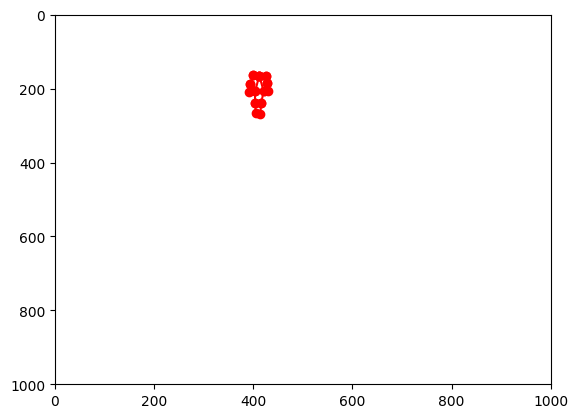

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

data = np.load('datasets/Poinst_Dataset/HC/gsm/natural/forward/gsm_f1/result.npy')

frames, joints, coords = data.shape

skeleton_connections = [
    (6, 8), (8, 10),   
    (5, 7), (7, 9),   
    (12, 14), (14, 16),  
    (11, 13), (13, 15), 
    (6, 17), (5, 17),
    (12, 17), (17, 11),
    # (0, 17), (0, 2),
    # (0, 1), (1, 3), (1, 4)
]

fig, ax = plt.subplots()
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.invert_yaxis()   

lines = [ax.plot([], [], 'ro-')[0] for _ in skeleton_connections]

def update(frame):
    
    curr = data[frame]
    joint17 = (curr[5] + curr[6]) / 2

    curr_extended = np.vstack([curr, joint17])

    for i, (j1, j2) in enumerate(skeleton_connections):
        
        x = [curr_extended[j1, 0], curr_extended[j2, 0]]
        y = [curr_extended[j1, 1], curr_extended[j2, 1]]
        lines[i].set_data(x, y)
    return lines

ani = FuncAnimation(fig, update, frames=frames, interval=30)
HTML(ani.to_jshtml())

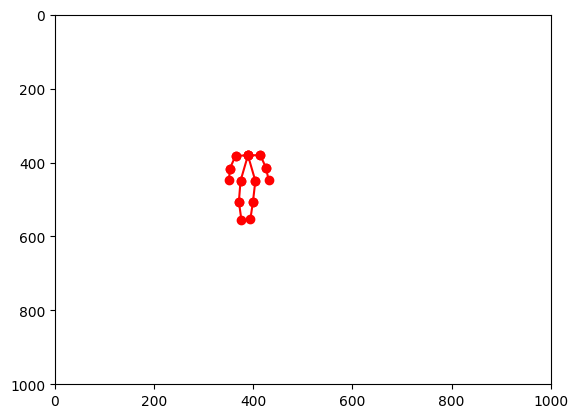

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

data = np.load('datasets/Poinst_Dataset/PD/Later_Sub2/natural/forward/Later_Sub2_f1/result.npy')

frames, joints, coords = data.shape

skeleton_connections = [
    (6, 8), (8, 10),  
    (5, 7), (7, 9),  
    (12, 14), (14, 16),  
    (11, 13), (13, 15), 
    (6, 17), (5, 17), 
    (12, 17), (17, 11), 
]

fig, ax = plt.subplots()
ax.set_xlim(0, 1000) 
ax.set_ylim(0, 1000)
ax.invert_yaxis()    
lines = [ax.plot([], [], 'ro-')[0] for _ in skeleton_connections]

def update(frame):
    curr = data[frame]

    joint17 = (curr[5] + curr[6]) / 2

    curr_extended = np.vstack([curr, joint17])

    for i, (j1, j2) in enumerate(skeleton_connections):
        x = [curr_extended[j1, 0], curr_extended[j2, 0]]
        y = [curr_extended[j1, 1], curr_extended[j2, 1]]
        lines[i].set_data(x, y)
    return lines

ani = FuncAnimation(fig, update, frames=frames, interval=30)
HTML(ani.to_jshtml())

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
from sklearn.metrics import accuracy_score, recall_score, f1_score
import time

# --- 1. DATA PREPROCESSING HELPERS ---
def calculate_distances(skeleton_data):
    """
    Input: (Frames, 17, 2)
    Output: (Frames, 78) - Euclidean distances between all pairs of 13 joints (head removed)
    """
    body_joints = skeleton_data[:, 5:17, :] # (Frames, 12, 2)
    joint17 = (skeleton_data[:, 5, :] + skeleton_data[:, 6, :]) / 2
    joints = np.concatenate([body_joints, joint17[:, np.newaxis, :]], axis=1) # (Frames, 13, 2)

    T, V, C = joints.shape
    distances = []
    # Calculate C(13, 2) = 78 combinations
    for i in range(V):
        for j in range(i + 1, V):
            # Euclidean distance
            dist = np.linalg.norm(joints[:, i, :] - joints[:, j, :], axis=1)
            distances.append(dist)

    return np.array(distances).T # (72, 78)

class PDWalkDataset(Dataset):
    def __init__(self, csv_file, root_dir, cache_dir='processed_distances'):
        self.root_dir = root_dir
        self.data_list = []
        # Create a cache directory to store calculated distances
        self.cache_dir = os.path.join(root_dir, cache_dir)
        os.makedirs(self.cache_dir, exist_ok=True)

        df = pd.read_csv(csv_file, header=None, sep=None, engine='python')

        print(f"Checking/Preparing cache for {csv_file}...")
        for _, row in df.iterrows():
            folder_rel_path = row[0]
            label = int(row[1])
            folder_full_path = os.path.join(root_dir, folder_rel_path)

            if os.path.exists(folder_full_path):
                clips = [f for f in os.listdir(folder_full_path) if f.endswith('.npy')]
                for clip in clips:
                    raw_path = os.path.join(folder_full_path, clip)

                    # Create a unique cache filename based on the original path
                    # e.g., HC_gsm_natural_forward_gsm_f1_Clip_0.npy
                    cache_name = raw_path.replace(root_dir, "").replace("/", "_").replace("\\", "_")
                    cache_path = os.path.join(self.cache_dir, cache_name)

                    # Pre-calculate and save if cache doesn't exist
                    if not os.path.exists(cache_path):
                        raw_data = np.load(raw_path)
                        dist_data = calculate_distances(raw_data)
                        np.save(cache_path, dist_data)

                    self.data_list.append((cache_path, label))
        print("Dataset ready.")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # Now we just load the pre-calculated distance file
        cache_path, label = self.data_list[idx]
        dist_data = np.load(cache_path) # (72, 78)

        # Standardize (we still do this on the fly as it's very fast)
        dist_data = (dist_data - np.mean(dist_data)) / (np.std(dist_data) + 1e-6)

        return torch.FloatTensor(dist_data), torch.LongTensor([label]).squeeze()

# --- 2. MODEL ARCHITECTURE ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerTower(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, use_pos_enc=True):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.use_pos_enc = use_pos_enc
        if use_pos_enc:
            self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=1024, 
                                                   dropout=0.01,
                                                   batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ls_layer = nn.Linear(d_model, 200) # d_fusion = 200 from paper

    def forward(self, x):
        # x: (Batch, Seq, Feat)
        x = self.embedding(x)
        if self.use_pos_enc:
            x = self.pos_encoder(x)
        x = self.transformer(x)
        x = torch.mean(x, dim=1) # Global Avg Pool to reduce dimension
        return F.softmax(self.ls_layer(x), dim=1)

class TensorFusion(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, fso, fco):
        # Add a constant dimension with value 1
        batch_size = fso.shape[0]
        ones = torch.ones(batch_size, 1).to(fso.device)

        fso_ext = torch.cat([fso, ones], dim=1) # (B, D+1)
        fco_ext = torch.cat([fco, ones], dim=1) # (B, D+1)

        # Outer product via Batch Matrix Multiplication
        fusion = torch.bmm(fso_ext.unsqueeze(2), fco_ext.unsqueeze(1))
        return fusion.view(batch_size, -1) # Flatten

class TwinTowerTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        # Step-wise (Temporal)
        self.step_tower = TransformerTower(78, 512, 8, 4, use_pos_enc=True)
        # Channel-wise (Spatial)
        self.chan_tower = TransformerTower(72, 512, 8, 4, use_pos_enc=False)

        self.fusion = TensorFusion()

        # Decoder
        fusion_dim = (200 + 1) ** 2
        self.decoder = nn.Sequential(
            nn.Linear(fusion_dim, 200), # d_hidden2 = 200
            nn.ReLU(),
            nn.Linear(200, 2), # Output 2 classes
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        # x: (Batch, 72, 78)
        fso = self.step_tower(x)

        # Transpose for Channel-wise: (Batch, 78, 72)
        x_chan = x.transpose(1, 2)
        fco = self.chan_tower(x_chan)

        f_fused = self.fusion(fso, fco)
        return self.decoder(f_fused)

# --- 3. TRAINING AND CROSS-VALIDATION LOOP ---

def run_cross_validation(project_root):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    csv_base = os.path.join(project_root, 'datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/')

    results = []

    for fold in range(5):
        print(f"\n{'='*20} FOLD {fold} {'='*20}")

        train_csv = os.path.join(csv_base, f'train_{fold}.csv')
        test_csv = os.path.join(csv_base, f'test_{fold}.csv')

        train_ds = PDWalkDataset(train_csv, project_root)
        test_ds = PDWalkDataset(test_csv, project_root)

        train_loader = DataLoader(train_ds, batch_size=100, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=100, shuffle=False)

        model = TwinTowerTransformer().to(device)
        optimizer = optim.Adagrad(model.parameters(), lr=1e-4)
        criterion = nn.NLLLoss()

        # Training
        print(f"Training with {device}...")
        model.train()
        for epoch in range(200): # Adjust epochs as needed
            total_loss = 0
            epoch_start=time.time()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                output = model(batch_x)
                loss = criterion(output, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            
            print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Time:{time.time()-epoch_start:.2f}")


        # Testing
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device)
                output = model(batch_x)
                preds = output.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch_y.numpy())

        # Metrics
        acc = accuracy_score(all_labels, all_preds)
        rec = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)

        print(f"Fold {fold} Results -> Accuracy: {acc:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
        results.append(acc)

        # Save Weights
        torch.save(model.state_dict(), f'twin_tower_fold_{fold}.pth')

    print(f"\nFinal Average Cross-Validation Accuracy: {np.mean(results):.4f}")

# --- EXECUTION ---

In [8]:
project_root = ''
run_cross_validation(project_root)


==================== FOLD 0 ====================
Checking/Preparing cache for datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/train_0.csv...
Dataset ready.
Checking/Preparing cache for datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/test_0.csv...
Dataset ready.
Training with cuda...
Epoch 1, Loss: 0.6946, Time:57.13
Epoch 2, Loss: 0.6912, Time:58.96
Epoch 3, Loss: 0.6888, Time:59.22
Epoch 4, Loss: 0.6872, Time:59.04
Epoch 5, Loss: 0.6851, Time:59.09
Epoch 6, Loss: 0.6834, Time:59.17
Epoch 7, Loss: 0.6819, Time:59.16
Epoch 8, Loss: 0.6806, Time:59.15
Epoch 9, Loss: 0.6788, Time:59.15
Epoch 10, Loss: 0.6775, Time:59.13
Epoch 11, Loss: 0.6761, Time:59.13
Epoch 12, Loss: 0.6747, Time:59.16
Epoch 13, Loss: 0.6735, Time:59.28
Epoch 14, Loss: 0.6718, Time:59.28
Epoch 15, Loss: 0.6704, Time:59.24
Epoch 16, Loss: 0.6690, Time:59.12
Epoch 17, Loss: 0.6677, Time:59.08
Epoch 18, Loss: 0.6660, Time:59.08
Epoch 19, Loss: 0.6647, Time:58.99
Epoch 20, Loss: 0.6632, T

In [9]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import os
from sklearn.metrics import accuracy_score, recall_score, f1_score

def get_metrics(model, loader, device):
    """Helper function to run inference and return metrics."""
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            output = model(batch_x)
            preds = output.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch_y.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return acc, rec, f1

def evaluate_saved_models_comprehensive(project_root):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    csv_base = os.path.join(project_root, 'datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/')
    
    # Accumulators for averages
    metrics_history = {
        'train_acc': [], 'train_rec': [], 'train_f1': [],
        'test_acc': [], 'test_rec': [], 'test_f1': []
    }

    print(f"Starting Full Evaluation (Train & Test) using saved weights...\n")

    for fold in range(5):
        weights_path = f'twin_tower_fold_{fold}.pth'
        train_csv = os.path.join(csv_base, f'train_{fold}.csv')
        test_csv = os.path.join(csv_base, f'test_{fold}.csv')

        if not os.path.exists(weights_path):
            print(f"Skipping Fold {fold}: Weights {weights_path} not found.")
            continue

        # 1. Load Data
        train_ds = PDWalkDataset(train_csv, project_root)
        test_ds = PDWalkDataset(test_csv, project_root)
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

        # 2. Load Model
        model = TwinTowerTransformer().to(device)
        model.load_state_dict(torch.load(weights_path, map_location=device))

        # 3. Get Metrics
        tr_acc, tr_rec, tr_f1 = get_metrics(model, train_loader, device)
        te_acc, te_rec, te_f1 = get_metrics(model, test_loader, device)

        # 4. Store Results
        metrics_history['train_acc'].append(tr_acc)
        metrics_history['train_rec'].append(tr_rec)
        metrics_history['train_f1'].append(tr_f1)
        metrics_history['test_acc'].append(te_acc)
        metrics_history['test_rec'].append(te_rec)
        metrics_history['test_f1'].append(te_f1)

        print(f"--- Fold {fold} ---")
        print(f"  TRAIN: Acc={tr_acc:.4f}, Rec={tr_rec:.4f}, F1={tr_f1:.4f}")
        print(f"  TEST : Acc={te_acc:.4f}, Rec={te_rec:.4f}, F1={te_f1:.4f}")

    # 5. Final Summary and Averages
    print(f"\n{'='*50}")
    print(f"{'FINAL 5-FOLD AVERAGE RESULTS':^50}")
    print(f"{'='*50}")
    print(f"{'Metric':<15} | {'Training':<15} | {'Testing':<15}")
    print(f"{'-'*15}|{'-'*17}|{'-'*15}")
    
    avg_metrics = {k: np.mean(v) for k, v in metrics_history.items()}
    
    print(f"{'Accuracy':<15} | {avg_metrics['train_acc']:<15.4f} | {avg_metrics['test_acc']:<15.4f}")
    print(f"{'Recall':<15} | {avg_metrics['train_rec']:<15.4f} | {avg_metrics['test_rec']:<15.4f}")
    print(f"{'F1-Score':<15} | {avg_metrics['train_f1']:<15.4f} | {avg_metrics['test_f1']:<15.4f}")
    print(f"{'='*50}")


In [13]:
import warnings
warnings.filterwarnings("ignore")

project_root = ""
evaluate_saved_models_comprehensive(project_root)

Starting Full Evaluation (Train & Test) using saved weights...

Checking/Preparing cache for datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/train_0.csv...
Dataset ready.
Checking/Preparing cache for datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/test_0.csv...
Dataset ready.
--- Fold 0 ---
  TRAIN: Acc=0.8830, Rec=0.8513, F1=0.8896
  TEST : Acc=0.7612, Rec=0.7934, F1=0.7741
Checking/Preparing cache for datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/train_1.csv...
Dataset ready.
Checking/Preparing cache for datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/test_1.csv...
Dataset ready.
--- Fold 1 ---
  TRAIN: Acc=0.8838, Rec=0.8436, F1=0.8905
  TEST : Acc=0.6023, Rec=0.3611, F1=0.4769
Checking/Preparing cache for datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/train_2.csv...
Dataset ready.
Checking/Preparing cache for datasets/CSVFolders/hrnet_pd_norm_natural_forward_2_class_5_fold/test_2.csv...
Dataset 